In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder

In [104]:
sales = pd.read_csv('Original Data.csv', encoding='latin-1')
sales.shape

(51290, 24)

In [105]:
sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [106]:
sales.drop(columns=['Row ID' ,'Order ID' ,'Customer ID','Postal Code','Product ID'] ,inplace=True)

In [107]:
sales['Order Date'] = pd.to_datetime(sales['Order Date'], dayfirst=True)
sales['Ship Date'] = pd.to_datetime(sales['Ship Date'], dayfirst=True)

In [108]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order Date      51290 non-null  datetime64[ns]
 1   Ship Date       51290 non-null  datetime64[ns]
 2   Ship Mode       51290 non-null  object        
 3   Customer Name   51290 non-null  object        
 4   Segment         51290 non-null  object        
 5   City            51290 non-null  object        
 6   State           51290 non-null  object        
 7   Country         51290 non-null  object        
 8   Market          51290 non-null  object        
 9   Region          51290 non-null  object        
 10  Category        51290 non-null  object        
 11  Sub-Category    51290 non-null  object        
 12  Product Name    51290 non-null  object        
 13  Sales           51290 non-null  float64       
 14  Quantity        51290 non-null  int64         
 15  Di

In [109]:
sales['Month'] = sales['Order Date'].dt.month
sales['Year'] = sales['Order Date'].dt.year
sales['Day_of_Week'] = sales['Order Date'].dt.dayofweek
sales['Is_Weekend'] = sales['Day_of_Week'].isin([5, 6]).astype(int)
sales['Total_sales'] = (sales['Sales']) * (sales['Quantity'])


In [110]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order Date      51290 non-null  datetime64[ns]
 1   Ship Date       51290 non-null  datetime64[ns]
 2   Ship Mode       51290 non-null  object        
 3   Customer Name   51290 non-null  object        
 4   Segment         51290 non-null  object        
 5   City            51290 non-null  object        
 6   State           51290 non-null  object        
 7   Country         51290 non-null  object        
 8   Market          51290 non-null  object        
 9   Region          51290 non-null  object        
 10  Category        51290 non-null  object        
 11  Sub-Category    51290 non-null  object        
 12  Product Name    51290 non-null  object        
 13  Sales           51290 non-null  float64       
 14  Quantity        51290 non-null  int64         
 15  Di

In [111]:
sales['Day_of_Month'] = sales['Order Date'].dt.day

In [112]:
encoder = LabelEncoder()

categorical_columns = ["Order Priority", "Ship Mode", "Segment", "Market", "Category", "Sub-Category", "Region"]

for col in categorical_columns:
    sales[col + "_Encoded"] = encoder.fit_transform(sales[col])

sales[[*categorical_columns, *[col + "_Encoded" for col in categorical_columns]]].head()

,Order Priority,Ship Mode,Segment,Market,Category,Sub-Category,Region,Order Priority_Encoded,Ship Mode_Encoded,Segment_Encoded,Market_Encoded,Category_Encoded,Sub-Category_Encoded,Region_Encoded
0,Critical,Same Day,Consumer,US,Technology,Accessories,East,0,1,0,6,2,0,6
1,Critical,Second Class,Corporate,APAC,Furniture,Chairs,Oceania,0,2,1,0,0,5,9
2,Medium,First Class,Consumer,APAC,Technology,Phones,Oceania,3,0,0,0,2,13,9
3,Medium,First Class,Home Office,EU,Technology,Phones,Central,3,0,2,4,2,13,3
4,Critical,Same Day,Consumer,Africa,Technology,Copiers,Africa,0,1,0,1,2,6,0


In [113]:
sales.drop(columns=categorical_columns, inplace=True)

In [114]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Order Date              51290 non-null  datetime64[ns]
 1   Ship Date               51290 non-null  datetime64[ns]
 2   Customer Name           51290 non-null  object        
 3   City                    51290 non-null  object        
 4   State                   51290 non-null  object        
 5   Country                 51290 non-null  object        
 6   Product Name            51290 non-null  object        
 7   Sales                   51290 non-null  float64       
 8   Quantity                51290 non-null  int64         
 9   Discount                51290 non-null  float64       
 10  Profit                  51290 non-null  float64       
 11  Shipping Cost           51290 non-null  float64       
 12  Month                   51290 non-null  int32 

In [115]:

Q1 = sales['Total_sales'].quantile(0.25)
Q3 = sales['Total_sales'].quantile(0.75)
IQR2 = Q3 - Q1
lower_bound2 = Q1 - 1.5*IQR2
upper_bound2 = Q3 + 1.5*IQR2
sales['Total_sales'] = sales['Total_sales'].apply(lambda x: sales['Total_sales'].mean() if x <= lower_bound2 or x >= upper_bound2 else x)

In [116]:
sales = sales.sort_index()

# Create lag features
sales['Sales_Lag_1D'] = sales['Total_sales'].shift(1)   # 1 day before
sales['Sales_Lag_7D'] = sales['Total_sales'].shift(7)   # 1 week before
sales['Sales_Lag_30D'] = sales['Total_sales'].shift(30) # 1 month before
sales['Sales_Lag_90D'] = sales['Total_sales'].shift(90) # 3 months before


In [117]:
# Handling Null Values
sales[['Sales_Lag_1D','Sales_Lag_7D','Sales_Lag_30D','Sales_Lag_90D']] = (
    sales[['Sales_Lag_1D','Sales_Lag_7D','Sales_Lag_30D','Sales_Lag_90D']].fillna(method='bfill')
)

In [118]:
sales.columns

Index(['Order Date', 'Ship Date', 'Customer Name', 'City', 'State', 'Country',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Shipping Cost', 'Month', 'Year', 'Day_of_Week', 'Is_Weekend',
       'Total_sales', 'Day_of_Month', 'Order Priority_Encoded',
       'Ship Mode_Encoded', 'Segment_Encoded', 'Market_Encoded',
       'Category_Encoded', 'Sub-Category_Encoded', 'Region_Encoded',
       'Sales_Lag_1D', 'Sales_Lag_7D', 'Sales_Lag_30D', 'Sales_Lag_90D'],
      dtype='object')

In [119]:
sales.drop(['Customer Name', 'Product Name', 'Order Date',
            'Ship Date',
                'City', 'State' ,'Country' , 'Sales', 
                'Region_Encoded','Segment_Encoded',

                ] ,axis=1 ,inplace=True)

In [120]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Quantity                51290 non-null  int64  
 1   Discount                51290 non-null  float64
 2   Profit                  51290 non-null  float64
 3   Shipping Cost           51290 non-null  float64
 4   Month                   51290 non-null  int32  
 5   Year                    51290 non-null  int32  
 6   Day_of_Week             51290 non-null  int32  
 7   Is_Weekend              51290 non-null  int64  
 8   Total_sales             51290 non-null  float64
 9   Day_of_Month            51290 non-null  int32  
 10  Order Priority_Encoded  51290 non-null  int64  
 11  Ship Mode_Encoded       51290 non-null  int64  
 12  Market_Encoded          51290 non-null  int64  
 13  Category_Encoded        51290 non-null  int64  
 14  Sub-Category_Encoded    51290 non-null

In [121]:
from sklearn.model_selection import train_test_split

X = sales.drop('Total_sales', axis=1)
y = sales['Total_sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

In [122]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[['Sales_Lag_1D','Sales_Lag_7D','Sales_Lag_30D','Sales_Lag_90D']] = scaler.fit_transform(X_train[['Sales_Lag_1D','Sales_Lag_7D','Sales_Lag_30D','Sales_Lag_90D']])
X_test[['Sales_Lag_1D','Sales_Lag_7D','Sales_Lag_30D','Sales_Lag_90D']] = scaler.transform(X_test[['Sales_Lag_1D','Sales_Lag_7D','Sales_Lag_30D','Sales_Lag_90D']])

In [123]:
fig = px.box(sales, x='Shipping Cost', title='Boxplot of Shipping Cost')
fig.show()

In [124]:
# handel shipping cost outliers
Q1 = sales['Shipping Cost'].quantile(0.25)
Q3 = sales['Shipping Cost'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
sales['Shipping Cost'] = sales['Shipping Cost'].apply(lambda x: sales['Shipping Cost'].mean() if x <= lower_bound or x >= upper_bound else x)


In [125]:
fig = px.box(sales, x='Shipping Cost', title='Boxplot of Shipping Cost')
fig.show()

In [126]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define the models
models = {
    "Linear Regression": LinearRegression(),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "Random Forest": RandomForestRegressor(random_state=30),
    "Extra Trees": ExtraTreesRegressor(random_state=30),
    "Gradient Boosting": GradientBoostingRegressor(random_state=30),
    # "Support Vector Regressor": SVR(),
    "XGBoost": XGBRegressor(random_state=30, verbosity=0)
}

# Evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    preds_test = model.predict(X_test)
    preds_train = model.predict(X_train)

    # Calculate metrics
    rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
    rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
    mae_test = mean_absolute_error(y_test, preds_test)
    mae_train = mean_absolute_error(y_train, preds_train)
    r2_test = r2_score(y_test, preds_test)
    r2_train = r2_score(y_train, preds_train)

    # Print results
    print(f"{name}:")
    print(f"  Train RMSE: {rmse_train:.4f} | Test RMSE: {rmse_test:.4f}")
    print(f"  Train MAE:  {mae_train:.4f} | Test MAE:  {mae_test:.4f}")
    print(f"  Train R²:   {r2_train:.4f}   | Test R²:   {r2_test:.4f}")
    print("-" * 50)

Linear Regression:
  Train RMSE: 289.2929 | Test RMSE: 291.7641
  Train MAE:  195.1973 | Test MAE:  194.6313
  Train R²:   0.6957   | Test R²:   0.6862
--------------------------------------------------
K-Nearest Neighbors:
  Train RMSE: 216.9567 | Test RMSE: 266.6964
  Train MAE:  125.7825 | Test MAE:  154.4976
  Train R²:   0.8288   | Test R²:   0.7378
--------------------------------------------------
Random Forest:
  Train RMSE: 64.0051 | Test RMSE: 175.1808
  Train MAE:  34.4921 | Test MAE:  93.7488
  Train R²:   0.9851   | Test R²:   0.8869
--------------------------------------------------
Extra Trees:
  Train RMSE: 0.0000 | Test RMSE: 177.8886
  Train MAE:  0.0000 | Test MAE:  96.7172
  Train R²:   1.0000   | Test R²:   0.8834
--------------------------------------------------
Gradient Boosting:
  Train RMSE: 184.9386 | Test RMSE: 191.2005
  Train MAE:  107.8532 | Test MAE:  109.7668
  Train R²:   0.8756   | Test R²:   0.8653
--------------------------------------------------
X

In [127]:
import xgboost as xgb
models = {
      
    "XGBoost": xgb.XGBRegressor(colsample_bytree= 0.8, gamma= 0, learning_rate= 0.05, max_depth= 5, n_estimators= 300, reg_alpha= 1, reg_lambda= 2, subsample= 0.8)
    
}

# Evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    preds_test = model.predict(X_test)
    preds_train = model.predict(X_train)

    # Calculate metrics
    rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
    rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
    mae_test = mean_absolute_error(y_test, preds_test)
    mae_train = mean_absolute_error(y_train, preds_train)
    r2_test = r2_score(y_test, preds_test)
    r2_train = r2_score(y_train, preds_train)

    # Print results
    print(f"{name}:")
    print(f"  Train RMSE: {rmse_train:.4f} | Test RMSE: {rmse_test:.4f}")
    print(f"  Train MAE:  {mae_train:.4f} | Test MAE:  {mae_test:.4f}")
    print(f"  Train R²:   {r2_train:.4f}   | Test R²:   {r2_test:.4f}")
    print("-" * 50)

XGBoost:
  Train RMSE: 152.8835 | Test RMSE: 171.0875
  Train MAE:  87.1663 | Test MAE:  95.4051
  Train R²:   0.9150   | Test R²:   0.8921
--------------------------------------------------


In [128]:
import pickle
best_model = models["XGBoost"]

with open("xgboost_sales_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model saved as 'xgboost_sales_model.pkl'")


Model saved as 'xgboost_sales_model.pkl'


In [129]:
# import xgboost as xgb
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import numpy as np

# # Initialize the model
# xgbr = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# # Define the parameter grid for XGBoost
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0],
#     'gamma': [0, 0.1, 0.3],
#     'reg_alpha': [0, 0.1, 1],
#     'reg_lambda': [1, 1.5, 2]
# }

# # Grid search setup
# grid_search = GridSearchCV(
#     estimator=xgbr,
#     param_grid=param_grid,
#     cv=5,
#     scoring='neg_root_mean_squared_error',  # Can use other metrics if needed
#     n_jobs=-1,
#     verbose=1
# )

# # Fit the grid search
# grid_search.fit(X_train, y_train)

# # Best parameters and model
# print("Best parameters:", grid_search.best_params_)
# best_model = grid_search.best_estimator_

# # Predict
# y_pred = best_model.predict(X_test)

# # Evaluation metrics
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# mae = mean_absolute_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)

# print(f"Tuned XGBoost RMSE: {rmse:.2f}")
# print(f"Tuned XGBoost MAE: {mae:.2f}")
# print(f"Tuned XGBoost R²: {r2:.4f}")

In [130]:
# After making hyperparameters this best parameters for XGBoost
import xgboost as xgb
models = {
     
    "XGBoost": xgb.XGBRegressor(colsample_bytree= 1.0, gamma= 0, learning_rate= 0.05, max_depth= 7, n_estimators= 300, reg_alpha= 1, reg_lambda= 1.5, subsample= 0.8)
    
}

# Evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    preds_test = model.predict(X_test)
    preds_train = model.predict(X_train)

    # Calculate metrics
    rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
    rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
    mae_test = mean_absolute_error(y_test, preds_test)
    mae_train = mean_absolute_error(y_train, preds_train)
    r2_test = r2_score(y_test, preds_test)
    r2_train = r2_score(y_train, preds_train)

    # Print results
    print(f"{name}:")
    print(f"  Train RMSE: {rmse_train:.4f} | Test RMSE: {rmse_test:.4f}")
    print(f"  Train MAE:  {mae_train:.4f} | Test MAE:  {mae_test:.4f}")
    print(f"  Train R²:   {r2_train:.4f}   | Test R²:   {r2_test:.4f}")
    print("-" * 50)

XGBoost:
  Train RMSE: 115.9847 | Test RMSE: 163.4262
  Train MAE:  65.7866 | Test MAE:  88.6036
  Train R²:   0.9511   | Test R²:   0.9016
--------------------------------------------------


In [131]:
# so we will use the model with without hyperparameters because it has a good performance in train and test data.

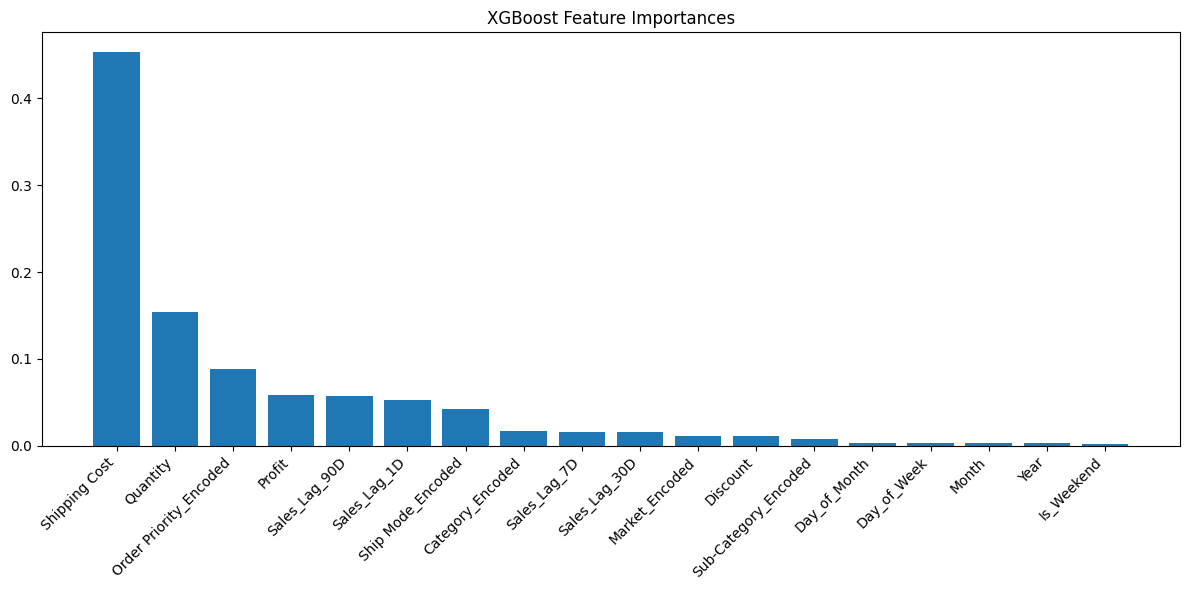

In [132]:
from xgboost import XGBRegressor
import pandas as pd
import matplotlib.pyplot as plt

# Use the already-trained XGBoost model
# If not trained yet, train like this:
# best_model = XGBRegressor(**best_params)
# best_model.fit(X_train, y_train)

# Get feature importances
importances = best_model.feature_importances_
features = X_train.columns

# Create a DataFrame for visualization
fi_df = pd.DataFrame({'Feature': features, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
plt.bar(fi_df['Feature'], fi_df['Importance'])
plt.xticks(rotation=45, ha='right')
plt.title('XGBoost Feature Importances')
plt.tight_layout()
plt.show()
